<a href="https://colab.research.google.com/github/mmahurin/Baton_Rouge-Crime-analysis-/blob/main/Python_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Problem statement:**

Crime in Baton Rouge varies by both time and place, but the city lacks a clear understanding of these patterns. It is not well known how crime frequency shifts throughout the day and year, how offenses differ across neighborhoods and districts, or which crimes occur most often in different time periods. By analyzing the Baton Rouge Police Crime Incidents dataset, this project seeks to uncover the spatiotemporal correlations between crime rates and their timing and location while also identifying the most frequently committed offenses and the areas with the highest crime rates. The goal is to reveal actionable patterns that can inform public safety strategies and resource allocation.

**2. Dataset:**

The Baton Rouge Police Crime Incidents dataset contains detailed records of crimes that occurred in the City of Baton Rouge and were handled by the Baton Rouge Police Department. The dataset begins in January 2021 and is updated regularly.

It includes information about each reported incident, such as:

a. Incident details: incident number, case/charge ID, charge date, report date, approval date, and whether the crime was attempted or completed.

b. Location information: street address, subaddress (if any), neighborhood, district, ZIP code, latitude/longitude, and geolocation points.

c. Crime classification: statute title, statute description, statute category, crime against (person/property/society), and NIBRS (National Incident-Based Reporting System) codes and descriptions.

d. Administrative fields: census block group, council district, and crime prevention district.


**3. Pseudocode to answer the following question(s) by analyzing the data:**

    A. Load and Explore Data
*Import the dataset into a dataframe.
Inspect the first few rows to understand the structure.
Identify key columns: date, time of day, crime type, neighborhood/district, etc.
Check for missing or inconsistent values.*  

    B. Prepare the Data
*Convert the date column into a proper datetime format.
Extract month, day of week, and time of day from the date/time fields.
Ensure the crime type and neighborhood fields are clean (no duplicates, consistent text formatting).
Create additional columns if needed (group, etc.).*

    C. Analysis Steps
**Question 1: What’s the highest crime committed each month?**

*Group the data by month and crime type.
Count the number of occurrences of each crime per month.
For each month, identify the crime type with the highest count.
Create a summary table showing the top crime per month.*

**Question 2: Which neighborhoods have the highest crime rates?**

*Group the data by neighborhood.
Count the total number of crimes in each neighborhood.
Sort the neighborhoods by crime count (highest to lowest).
Create a summary table showing the highest crime rate neighborhoods.*

**Question 3: What is the highest occurring crime overall?**

*Group the data by crime type.
Count the number of occurrences of each crime.
Identify the crime with the maximum count.
Create a summary table showing the highest occurring crimes in descending order.*

**Question 4: Is the crime rate higher after hours compared to daytime?**

*Group crimes into day/night.
Calculate average daily counts.
Normality Distribution Test.
Compare with an independent sample t-test (if normally distributed or Man-Whitney), or  Mann–Whitney U test (non-parametric alternative to compare two independent groups) if distribution is not normal.*

**Question 5: Is there an association between neighborhood/district area and crime type?**

*Group crimes by neighborhood vs crime type.
Apply a Chi-Square Test of Independence, or Fisher’s Exact Test if expected cell counts in the contingency table are too low
Interpret significance (p-value) to determine if crime type is related to the neighborhood*

**Question 6: Is there a linear relationship between month of the year and total crime counts?**

*Encode months numerically (January = 1, February = 2, … December = 12)
Aggregate crimes by month (get total monthly crime counts)
Apply Pearson correlation between month number and monthly crime counts, or Spearman rank correlation (non-parametric, monotonic relationship) if distribution is not normal.
Interpret correlation coefficient (positive/negative trend across months) and p-value (significance)*

**4. Team members' work:**

All team members collaborated equally on every section of the project. We worked together to develop the problem statement, describe the dataset, write the pseudocode, draft the Python code, complete the AI comparison, craft the final poster, and the final Notebook.
Matt: 20%, Rigas: 20%, Gemima: 20%, Arthur: 20%, Anastasiya: 20%.

**5. Interpretation and Communication of the Results:**

Theft is the dominant crime type across the board, theft is the most significant crime-related challenge in Baton Rouge. It was the most frequently reported crime overall, with 17,420 incidents recorded in the dataset. This trend holds true throughout the year, as theft was also the top-reported crime in every single month. This consistency suggests that theft is a persistent issue rather than a seasonal one and warrants continuous attention from law enforcement and community safety programs.

    Crime Hotspots are Clearly Identifiable

Our analysis shows that crime is not evenly distributed across the city. Certain neighborhoods experience a much higher volume of incidents. Specifically, North Baton Rouge stands out as the area with the highest crime rate, reporting 10,630 incidents. Other highly affected neighborhoods include Scotlandville (7,989 incidents) and Jones Creek (7,731 incidents). Identifying these hotspots is the first step toward targeted interventions, such as increased police presence or community-based prevention programs, to address the specific needs of these areas.

    No Significant Difference Between Daytime and Nighttime Crime

A surprising finding from our analysis is that there is no statistically significant difference between the crime rates during the day and those at night. While the average number of crimes is slightly higher during the day, our statistical test (the Mann-Whitney U test) showed that this difference is not large enough to be considered meaningful. This challenges the common assumption that more crime happens after dark and suggests that resources for crime prevention should be allocated consistently throughout a 24-hour period.

    Crime Types are Widespread, Not Neighborhood-Specific

We investigated whether certain types of crimes are more likely to occur in specific neighborhoods (e.g., comparing high-crime areas to low-crime areas). Our analysis, using a Chi-Square test, found no significant link between the type of neighborhood and the type of crime committed there. In simple terms, this means that both common and rare crimes are distributed similarly across all neighborhoods, regardless of their overall crime rate. This suggests that crime prevention strategies should be broad-based rather than focused on specific offenses in particular areas.

    Crime is Trending Downward

An interesting discovery in our findings is that throughout the course of the year, there is a  strong downward trend in crime counts from January to September. Our correlation analysis revealed a significant decrease in the number of incidents from the beginning of the year to the end. This would be an area that would warrant further research to find out why.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 UPLOAD THE CSV FILE INTO A FOLDER NAMED 'data' VIA YOUR MACHINE

 You need to upload the file to collab everytime as it is on stored in the session state.

In [ ]:
# Reading data file
import pandas as pd

police_df = pd.read_csv("Baton_Rouge_Police_Crime_Incidents.csv", encoding="latin1")

# M {


#Filter frame with only rows that have values in zip and district
#This can be built on to filter via any column. .notna() means not null. For fun.
filtered_police_df = police_df[police_df['ZIP CODE'].notna() & police_df['DISTRICT'].notna()]

# display(filtered_police_df)


#1. Cleaning of the data, prepping for #2'

# adding missing fields of CITY and STATE to the data frame.
# we dont need these values but this is how you add data to a column
cleaned_police_df = police_df

cleaned_police_df['CITY'].fillna('BATON ROUGE'),
cleaned_police_df['STATE'].fillna('LA')

#display(cleaned_police_df)


#2a. Descrptive Statistics
#police_df.describe()

#2b. Patterns (pearson Coorelation)

#2c. Function for additional data analysis I.e


# Question 1: What’s the highest crime committed each month?
  # Count how many times each Statute Desecription (crime) appears
crime_counts = police_df['STATUTE DESCRIPTION'].value_counts()

  # Get the most frequent CHARGE ID and its count
most_common_crime = crime_counts.idxmax()
most_common_count = crime_counts.max()
print(f"The most common crime is {most_common_crime} with {most_common_count} occurrences.")

# Convert CHARGE DATE to datetime
police_df['CHARGE DATE'] = pd.to_datetime(police_df['CHARGE DATE'], errors='coerce')

# Extract month name (or number)
police_df['Month'] = police_df['CHARGE DATE'].dt.month_name()  # or .dt.month for numeric

# Group by month and crime type, count occurrences
monthly_crime_counts = police_df.groupby(['Month', 'STATUTE DESCRIPTION']).size().reset_index(name='Count')

# Sort and get the top crime per month
most_common_crime_by_month = monthly_crime_counts.sort_values(['Month', 'Count'], ascending=[True, False]) \
                                                  .drop_duplicates(subset=['Month'])

# Display results
print(most_common_crime_by_month)

  #Neighborhood with the highest crime
most_common_neighborhood = police_df['NEIGHBORHOOD'].value_counts().idxmax()
most_common_count = police_df['NEIGHBORHOOD'].value_counts().max()
print(f"The neighborhood with the highest crime count is {most_common_neighborhood} with {most_common_count} crimes.")


# } M

/tmp/ipython-input-3734826269.py:4: DtypeWarning: Columns (1,11) have mixed types. Specify dtype option on import or set low_memory=False.
  police_df = pd.read_csv("Baton_Rouge_Police_Crime_Incidents.csv", encoding="latin1")


The most common crime is THEFT with 17420 occurrences.
          Month STATUTE DESCRIPTION  Count
493       April               THEFT   1461
1047     August               THEFT   1523
1624   December               THEFT   1523
2207   February               THEFT   1424
2800    January               THEFT   1482
3332       July               THEFT   1472
3846       June               THEFT   1320
4438      March               THEFT   1565
5023        May               THEFT   1306
5519   November               THEFT   1428
6040    October               THEFT   1517
6531  September               THEFT   1399
The neighborhood with the highest crime count is NORTH BATON ROUGE with 10630 crimes.


/tmp/ipython-input-3489274261.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  theft_by_month['Month'] = pd.Categorical(theft_by_month['Month'], categories=month_order, ordered=True)


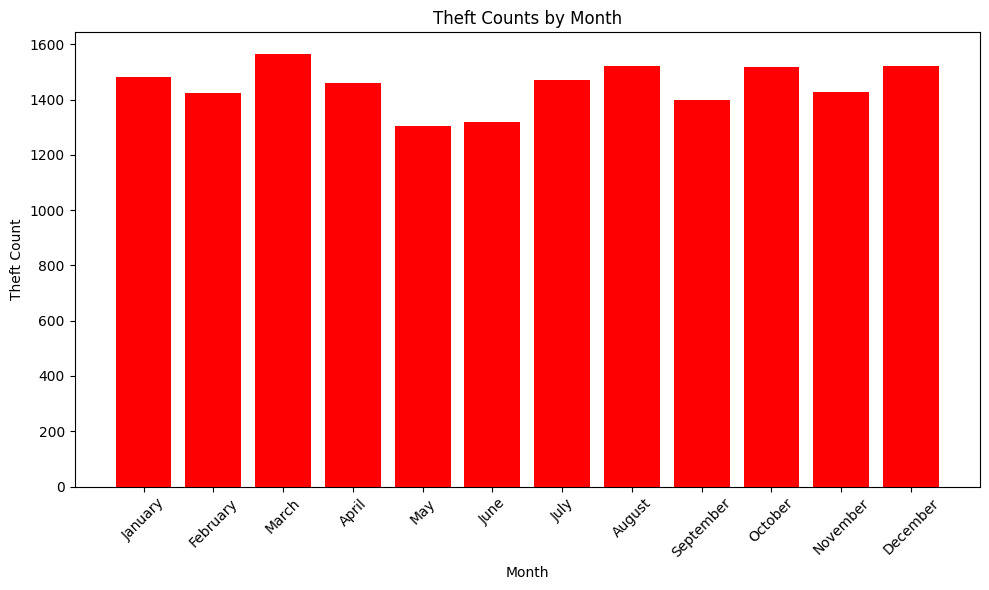

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

theft_by_month = monthly_crime_counts[monthly_crime_counts['STATUTE DESCRIPTION'] == 'THEFT']

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
theft_by_month['Month'] = pd.Categorical(theft_by_month['Month'], categories=month_order, ordered=True)
theft_by_month = theft_by_month.sort_values('Month')

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(theft_by_month['Month'], theft_by_month['Count'], color='red')
plt.xlabel('Month')
plt.ylabel('Theft Count')
plt.title('Theft Counts by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Question 1 Answer:
The results indicate that theft is consistently the highest occurring crime each month across the dataset. Monthly counts for theft range from 1,306 (May) to 1,565 (March), with a summary table showing theft dominating every month (e.g., 1,482 in January, 1,523 in August and December. In the bar chart above the consistency is clearly illustrated throughout the months.

In [ ]:
# Question 2: Which neighborhoods have the highest crime rates?

import pandas as pd

# Group data by neighborhood and count total crimes
neighborhood_crime_counts = police_df.groupby('NEIGHBORHOOD').size().reset_index(name='Crime Count')

# Sort by crime count in descending order
sorted_neighborhoods = neighborhood_crime_counts.sort_values(by='Crime Count', ascending=False)

# Create summary table (top 10 for brevity, adjust as needed)
summary_table = sorted_neighborhoods.head(10)

# Display results
print("Neighborhoods with the Highest Crime Rates:")
print(summary_table)

Neighborhoods with the Highest Crime Rates:
             NEIGHBORHOOD  Crime Count
33      NORTH BATON ROUGE        10630
41          SCOTLANDVILLE         7989
24            JONES CREEK         7731
36  OLD SOUTH BATON ROUGE         7711
3              BROOKSTOWN         7445
30               MID CITY         6436
47           SOUTH CAMPUS         6419
10          DELMONT PLACE         5682
34  NORTH SHERWOOD FOREST         5533
20       ISTROUMA / DIXIE         5044


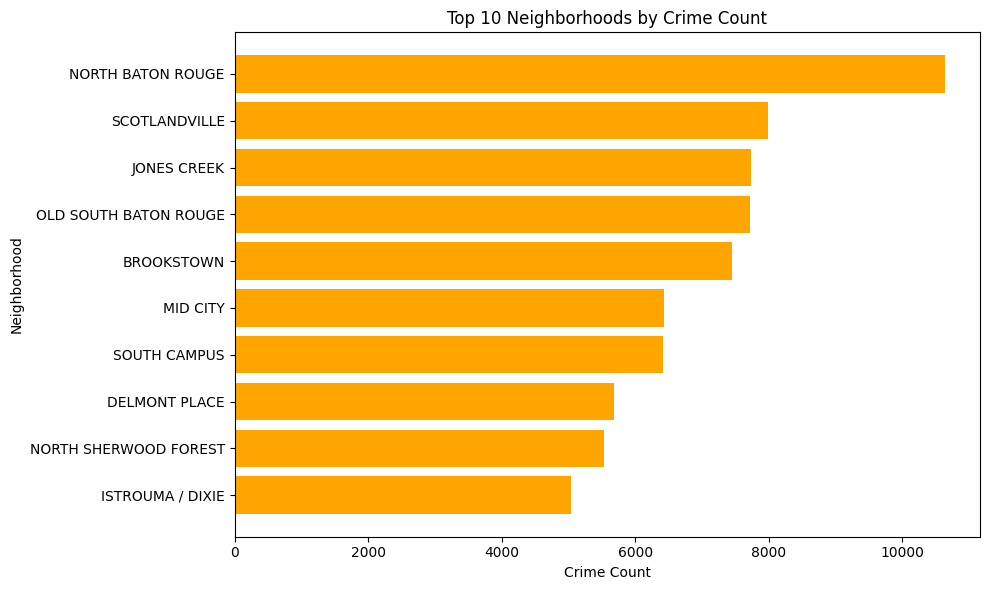

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

top_10_neighborhoods = sorted_neighborhoods.head(10)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_10_neighborhoods['NEIGHBORHOOD'], top_10_neighborhoods['Crime Count'], color='orange')
plt.xlabel('Crime Count')
plt.ylabel('Neighborhood')
plt.title('Top 10 Neighborhoods by Crime Count')
plt.gca().invert_yaxis()  # Highest at top
plt.tight_layout()
plt.show()

Question 2 Answer:
The results indicate that North Baton Rouge has the highest crime rate with 10,630 incidents, followed by Scotlandville (7,989) and Jones Creek (7,731). A summary table of the top 10 neighborhoods ranks them by total crime count in descending order, highlighting these areas as the most affected.

In [ ]:
# Question 3: What is the highest occurring crime overall?

import pandas as pd

# Group data by crime type and count occurrences
crime_counts = police_df.groupby('STATUTE DESCRIPTION').size().reset_index(name='Crime Count')

# Sort by crime count in descending order
sorted_crimes = crime_counts.sort_values(by='Crime Count', ascending=False)

# Identify the crime with the maximum count
most_common_crime = sorted_crimes.iloc[0]['STATUTE DESCRIPTION']
most_common_count = sorted_crimes.iloc[0]['Crime Count']

# Create summary table (top 10 for brevity, adjust as needed)
summary_table = sorted_crimes.head(10)

# Display results
print(f"The highest occurring crime is {most_common_crime} with {most_common_count} occurrences.")
print("\nTop Crime Types by Count:")
print(summary_table)

The highest occurring crime is THEFT with 17420 occurrences.

Top Crime Types by Count:
                                    STATUTE DESCRIPTION  Crime Count
1014                                              THEFT        17420
943                                     SIMPLE BURGLARY        12387
954                  SIMPLE CRIMINAL DAMAGE TO PROPERTY        12010
938                                      SIMPLE BATTERY         6316
1032                       THEFT OF GOODS (SHOPLIFTING)         6103
1028                          THEFT OF A MOTOR VEHICLE.         5267
277                              DOMESTIC ABUSE BATTERY         3616
780                             POSSESSION OF MARIJUANA         3109
513   ILLEGAL USE OF WEAPONS OR DANGEROUS INSTRUMENT...         3005
448                                            FUGITIVE         2880


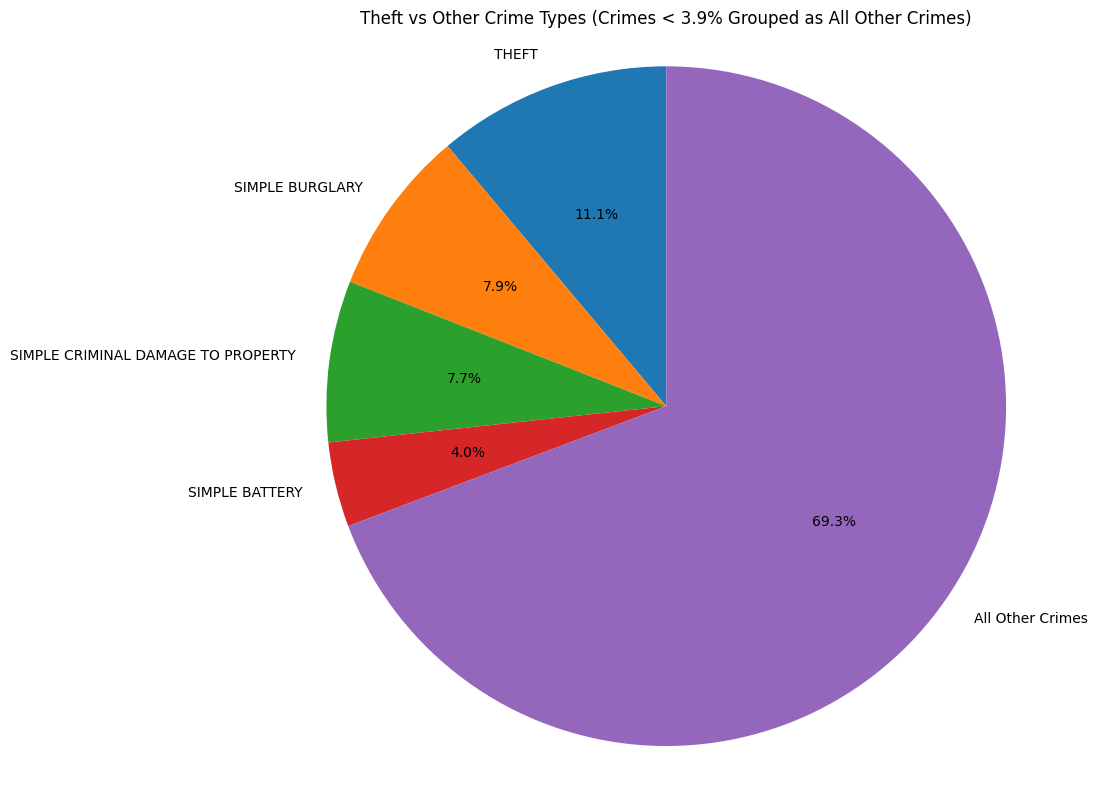

In [ ]:
# "In the analyzed data, theft was consistently the most frequent crime each month. The pie chart below illustrates how often theft occurred compared to other crime types throughput the dataset."

import matplotlib.pyplot as plt
import pandas as pd

# Count occurrences of each crime type
crime_counts = police_df['STATUTE DESCRIPTION'].value_counts()

# Calculate total crimes and percentages
total_crimes = crime_counts.sum()
percentages = (crime_counts / total_crimes * 100)

# Filter crimes with >= 3.9% and group others
significant_crimes = percentages[percentages >= 3.9]
other_crimes_count = crime_counts[percentages < 3.9].sum()

# Create new Series with significant crimes and "All Other Crimes"
final_counts = pd.concat([significant_crimes, pd.Series({'All Other Crimes': other_crimes_count * 100 / total_crimes})])

# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie(final_counts, labels=final_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Theft vs Other Crime Types (Crimes < 3.9% Grouped as All Other Crimes)')
plt.axis('equal')  # Equal aspect ratio ensures pie chart is circular
plt.tight_layout()
plt.show()

Question 3 Answer: The results indicate that theft is the highest occurring crime overall with 17,420 incidents. A summary table of the top 10 crime types ranks them in descending order, with simple burglary (12,387) and simple criminal damage to property (12,010) as the next most frequent.

In [ ]:
# Question 4: Is the crime rate higher after hours compared to daytime?

import pandas as pd
from scipy import stats


# Step 1: Group crimes into day/night
# Extract hour from 'CHARGE DATE'
police_df['Hour'] = police_df['CHARGE DATE'].dt.hour

# Define 'Period': Day (6 AM to 6 PM, hours 6-17), Night (6 PM to 6 AM, hours 18-23 and 0-5)
police_df['Period'] = police_df['Hour'].apply(lambda h: 'Day' if 6 <= h < 18 else 'Night')

# Extract date for daily grouping
police_df['Date'] = police_df['CHARGE DATE'].dt.date

# Group by Date and Period, count crimes
daily_counts = police_df.groupby(['Date', 'Period']).size().reset_index(name='Count')

# Pivot to have Day and Night columns, fill missing with 0
daily_pivot = daily_counts.pivot(index='Date', columns='Period', values='Count').fillna(0)

# Get lists of daily counts
day_counts = daily_pivot['Day']
night_counts = daily_pivot['Night']

# Step 2: Calculate average daily counts
avg_day = day_counts.mean()
avg_night = night_counts.mean()
print(f"Average daily daytime crimes: {avg_day:.2f}")
print(f"Average daily nighttime crimes: {avg_night:.2f}")

# Step 3: Normality Distribution Test
# Use Shapiro-Wilk test for normality on day and night counts
# To judge if distribution is normal: If p-value > 0.05, fail to reject null hypothesis (data is normally distributed).
# If p-value <= 0.05, reject null (data not normally distributed).
# Note: For large samples, test may detect minor deviations; visual inspection (histograms) or Q-Q plots recommended additionally.
shapiro_day = stats.shapiro(day_counts)
shapiro_night = stats.shapiro(night_counts)

print(f"Shapiro-Wilk test for Day: statistic={shapiro_day.statistic:.4f}, p-value={shapiro_day.pvalue:.4f}")
print(f"Shapiro-Wilk test for Night: statistic={shapiro_night.statistic:.4f}, p-value={shapiro_night.pvalue:.4f}")

is_normal_day = shapiro_day.pvalue > 0.05
is_normal_night = shapiro_night.pvalue > 0.05

# Step 4: Compare with t-test if both normal, else Mann-Whitney U test
if is_normal_day and is_normal_night:
    # Independent t-test (alternative='greater' to test if night > day)
    t_test_result = stats.ttest_ind(night_counts, day_counts, alternative='greater')
    test_name = "Independent t-test"
    p_value = t_test_result.pvalue
else:
    # Mann-Whitney U test (non-parametric, alternative='greater')
    mw_test_result = stats.mannwhitneyu(night_counts, day_counts, alternative='greater')
    test_name = "Mann-Whitney U test"
    p_value = mw_test_result.pvalue

print(f"{test_name} p-value: {p_value:.4f}")

# Conclusion
if p_value < 0.05:
    print("The crime rate is significantly higher at night compared to daytime (p < 0.05).")
else:
    print("No significant difference; crime rate is not higher at night (p >= 0.05).")

Average daily daytime crimes: 36.72
Average daily nighttime crimes: 29.79
Shapiro-Wilk test for Day: statistic=0.9162, p-value=0.0000
Shapiro-Wilk test for Night: statistic=0.9191, p-value=0.0000
Mann-Whitney U test p-value: 1.0000
No significant difference; crime rate is not higher at night (p >= 0.05).


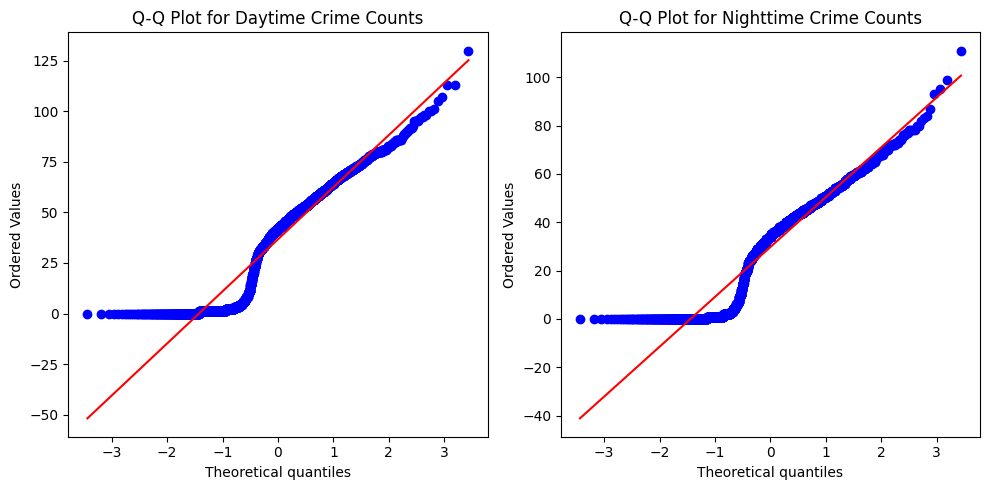

In [ ]:
# Q-Q Plots(to verify the distribution result)

import matplotlib.pyplot as plt
import scipy.stats as stats


police_df['Hour'] = police_df['CHARGE DATE'].dt.hour
police_df['Period'] = police_df['Hour'].apply(lambda h: 'Day' if 6 <= h < 18 else 'Night')
police_df['Date'] = police_df['CHARGE DATE'].dt.date
daily_counts = police_df.groupby(['Date', 'Period']).size().reset_index(name='Count')
daily_pivot = daily_counts.pivot(index='Date', columns='Period', values='Count').fillna(0)
day_counts = daily_pivot['Day']
night_counts = daily_pivot['Night']

# Create figure for Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Q-Q plot for Day counts
stats.probplot(day_counts, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot for Daytime Crime Counts')

# Q-Q plot for Night counts
stats.probplot(night_counts, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot for Nighttime Crime Counts')

plt.tight_layout()
plt.show()

The Q-Q Plots verify teh results of the Shapiro-Wilk test which indicated non-normality with p-values of 0.0000 for both day and night crime counts

/tmp/ipython-input-2159276963.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily_long, x='Period', y='Crime Count', palette=['blue', 'red'])


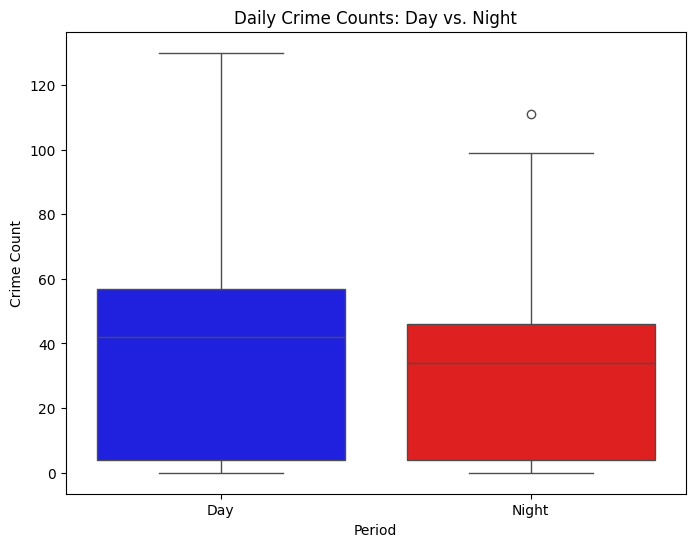

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


daily_long = daily_pivot.reset_index().melt(id_vars='Date', var_name='Period', value_name='Crime Count')

plt.figure(figsize=(8, 6))
sns.boxplot(data=daily_long, x='Period', y='Crime Count', palette=['blue', 'red'])
plt.title('Daily Crime Counts: Day vs. Night')
plt.ylabel('Crime Count')
plt.show()

**Question 4 Answer**:

The results indicate that the average daily crime count is higher during the day (36.72) than at night (29.79). The Shapiro-Wilk tests show p-values of 0.0000 for both day and night, indicating non-normal distributions (p < 0.05), so the Mann-Whitney U test was used. Its p-value of 1.0000 suggests no significant evidence that nighttime crime rates are higher than daytime rates,as illustrated in the boxplot above.

In [ ]:
# Question 5: Is there an association between neighborhood/district area and crime type?


import pandas as pd
from scipy import stats

# Step 1: Categorize neighborhoods and crimes into binary groups for 2x2 table
# All data is used: Neighborhoods ranked by crime frequency, split at 50% percentile (High: top 50% frequent, Low: bottom 50%)
# Crimes ranked by occurrence, split similarly (Common: top 50% frequent, Rare: bottom 50%)
neigh_freq = police_df['NEIGHBORHOOD'].value_counts()
crime_freq = police_df['STATUTE DESCRIPTION'].value_counts()

police_df['Neigh_Cat'] = pd.cut(
    police_df['NEIGHBORHOOD'].map(neigh_freq).rank(pct=True),
    bins=2,
    labels=['Low Frequency Neighborhoods', 'High Frequency Neighborhoods']
)

police_df['Crime_Cat'] = pd.cut(
    police_df['STATUTE DESCRIPTION'].map(crime_freq).rank(pct=True),
    bins=2,
    labels=['Rare Crimes', 'Common Crimes']
)

# Step 2: Create 2x2 contingency table
contingency_table = pd.crosstab(police_df['Neigh_Cat'], police_df['Crime_Cat'])

print("2x2 Contingency Table:")
print(contingency_table)

# Step 3: Apply Chi-Square Test of Independence
# Tests if neighborhood frequency category is independent of crime frequency category
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Test Results:")
print(f"Chi2 statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# Check for low expected counts
low_expected = (expected < 5).sum()
print(f"Cells with expected count < 5: {low_expected} (adequate if 0)")

# Step 4: Interpret significance
alpha = 0.05
if p_value < alpha:
    print(f"\nSignificant association between neighborhood and crime type (p = {p_value:.4f} < {alpha}).")
else:
    print(f"\nNo significant association (p = {p_value:.4f} >= {alpha}).")

2x2 Contingency Table:
Crime_Cat                     Rare Crimes  Common Crimes
Neigh_Cat                                               
Low Frequency Neighborhoods         32099          39040
High Frequency Neighborhoods        33974          40909

Chi-Square Test Results:
Chi2 statistic: 0.8951
p-value: 0.3441
Degrees of freedom: 1
Cells with expected count < 5: 0 (adequate if 0)

No significant association (p = 0.3441 >= 0.05).


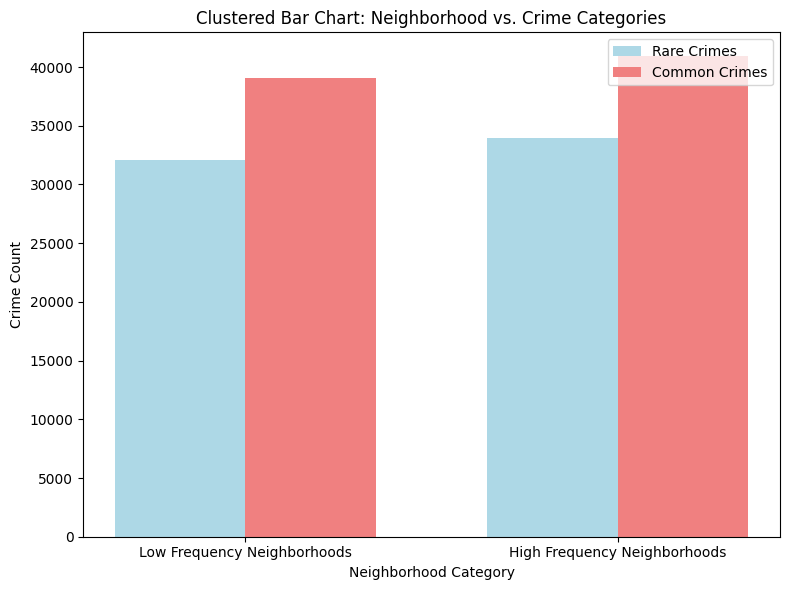

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Positions for bars
x = np.arange(len(contingency_table.index))  # 2 positions for Low and High

# Width of bars
width = 0.35

# Create clustered bar chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, contingency_table['Rare Crimes'], width, label='Rare Crimes', color='lightblue')
ax.bar(x + width/2, contingency_table['Common Crimes'], width, label='Common Crimes', color='lightcoral')

# Customize
ax.set_xlabel('Neighborhood Category')
ax.set_ylabel('Crime Count')
ax.set_title('Clustered Bar Chart: Neighborhood vs. Crime Categories')
ax.set_xticks(x)
ax.set_xticklabels(contingency_table.index)
ax.legend()
plt.tight_layout()
plt.show()

**Question 5 Answer**: The results indicate no significant association between neighborhood frequency categories (High vs. Low crime areas) and crime frequency categories (Common vs. Rare crimes), as the Chi-Square p-value (0.3441) exceeds 0.05. This suggests crime types are distributed similarly across neighborhood types in your dataset.
The contingency table,and the barchart, show balanced counts, supporting the test's validity (no low expected cells).

Monthly Crime Counts:
    Month_Num  Crime_Count
0           1        14773
1           2        13575
2           3        15101
3           4        14535
4           5        13540
5           6        11846
6           7        12598
7           8        13341
8           9        10778
9          10        12442
10         11        11774
11         12        12282

Shapiro-Wilk Normality Test on Crime Counts: statistic=0.9646, p-value=0.8465
Crime counts are normally distributed (p > 0.05); Pearson correlation is appropriate.

Pearson Correlation Coefficient: -0.7678
p-value: 0.0035
Significant negative linear relationship: Crimes decrease linearly over the year (p < 0.05).


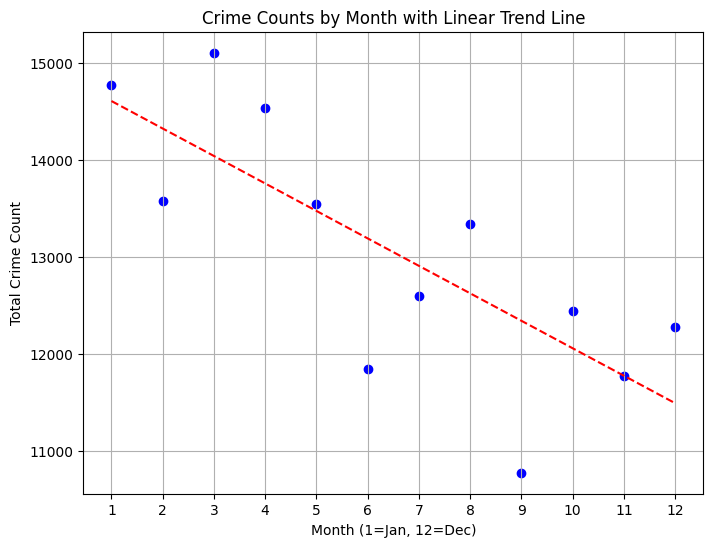

In [ ]:
# Question 6: Is there a linear relationship between month of the year and total crime counts?

import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Group crimes by month and count total crimes per month
police_df['Month_Num'] = police_df['CHARGE DATE'].dt.month  # 1=Jan, 12=Dec
monthly_crimes = police_df.groupby('Month_Num').size().reset_index(name='Crime_Count')

# Step 1.5: Normality test on Crime_Count (Shapiro-Wilk for small n=12)
# Null hypothesis: data is normally distributed. If p > 0.05, assume normality.
shapiro_stat, shapiro_p = stats.shapiro(monthly_crimes['Crime_Count'])
print("Monthly Crime Counts:")
print(monthly_crimes)
print(f"\nShapiro-Wilk Normality Test on Crime Counts: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("Crime counts are normally distributed (p > 0.05); Pearson correlation is appropriate.")
else:
    print("Crime counts are not normally distributed (p <= 0.05); consider Spearman correlation instead.")

# Step 2: Test for linear relationship using Pearson correlation (if normal)
correlation, p_value = stats.pearsonr(monthly_crimes['Month_Num'], monthly_crimes['Crime_Count'])

print(f"\nPearson Correlation Coefficient: {correlation:.4f}")
print(f"p-value: {p_value:.4f}")

# Step 3: Interpret results
alpha = 0.05
if p_value < alpha:
    if correlation > 0:
        print("Significant positive linear relationship: Crimes increase linearly over the year (p < 0.05).")
    else:
        print("Significant negative linear relationship: Crimes decrease linearly over the year (p < 0.05).")
else:
    print("No significant linear relationship between month and crime counts (p >= 0.05).")

# Visualizing with scatter plot and trend line
plt.figure(figsize=(8, 6))
plt.scatter(monthly_crimes['Month_Num'], monthly_crimes['Crime_Count'], color='blue')
z = np.polyfit(monthly_crimes['Month_Num'], monthly_crimes['Crime_Count'], 1)
p = np.poly1d(z)
plt.plot(monthly_crimes['Month_Num'], p(monthly_crimes['Month_Num']), "r--")
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Total Crime Count')
plt.title('Crime Counts by Month with Linear Trend Line')
plt.xticks(monthly_crimes['Month_Num'])
plt.grid(True)
plt.show()

**Question 6 Answer**: The results show a strong negative linear correlation (r = -0.7678, p = 0.0035) between month and crime counts, indicating a significant downward trend in crimes over the year (e.g., peaking in January at 14,773 and dropping to 10,778 in September). This suggests a seasonal decline, assuming the data has been collected evenly throughout the dataset's period (beginning January 1, 2021, with regular updates and no noted gaps).
